## Exploratory Data Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load train data

In [3]:
url_raw_train = "../data/raw/trainset.csv"
df_train = pd.read_csv(url_raw_train, index_col=0)
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
19019,-121.96,38.36,11.0,3208.0,790.0,1772.0,694.0,2.7434,218800.0,INLAND,2
5789,-118.25,34.15,32.0,1377.0,444.0,768.0,422.0,2.2621,187500.0,<1H OCEAN,2
19627,-121.03,37.32,42.0,2905.0,561.0,1457.0,551.0,2.2566,82100.0,INLAND,2
18363,-122.11,37.31,7.0,189.0,26.0,84.0,29.0,13.8093,500001.0,<1H OCEAN,5
10939,-117.89,33.73,32.0,728.0,134.0,837.0,135.0,4.0769,163900.0,<1H OCEAN,4


### Exploration

In [4]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 19019 to 2606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16339 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  str    
 10  income_cat          16512 non-null  int64  
dtypes: float64(9), int64(1), str(1)
memory usage: 1.5 MB


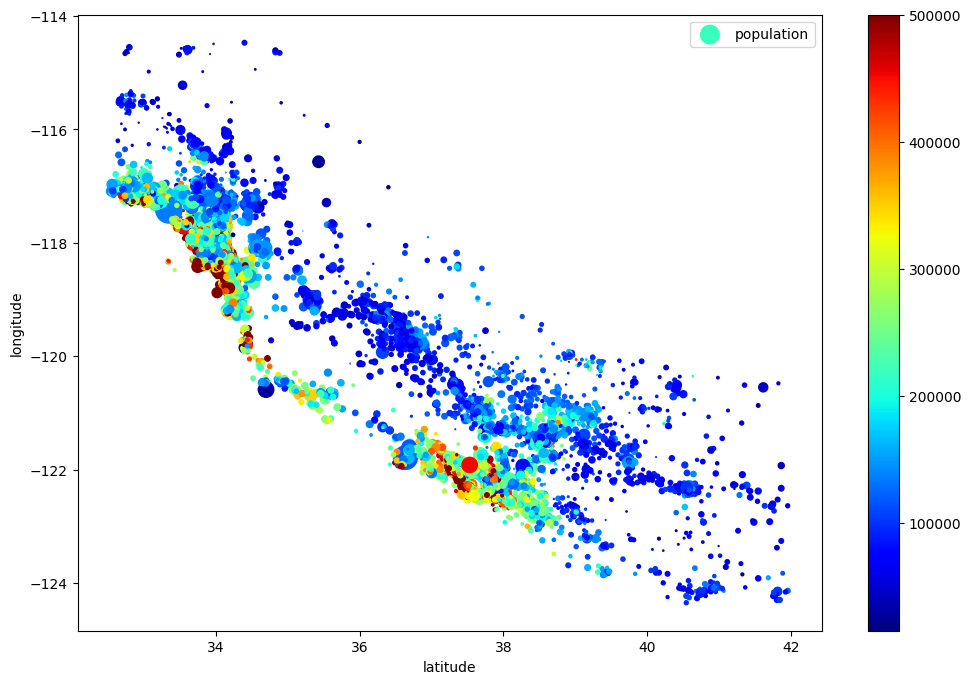

In [5]:
df_train.plot.scatter(x="latitude", y="longitude",
                      s=df_train['population'] / 100, label="population",
                      c=df_train['median_house_value'], cmap='jet', 
                      figsize=(12,8))

plt.show()

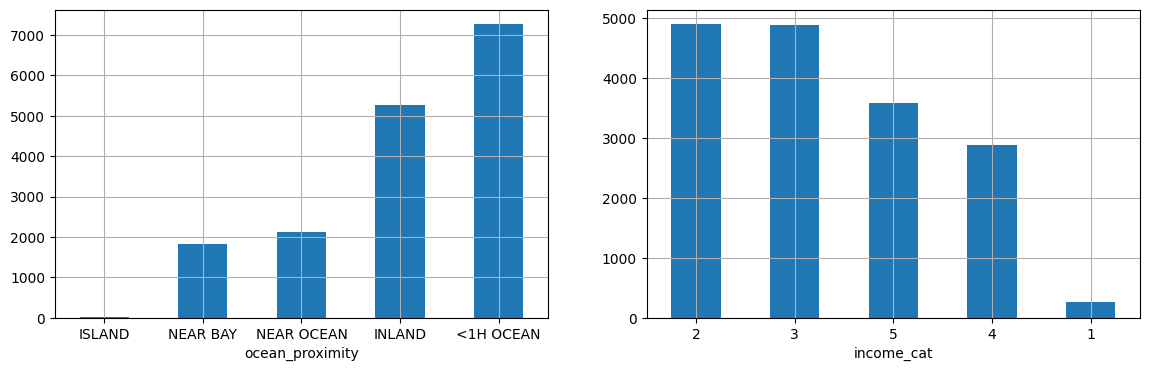

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

ocean_proximity_cat = df_train["ocean_proximity"].value_counts().sort_values()
ocean_proximity_cat.plot.bar(ax=axes[0], rot=0, grid=True)

income_cat = df_train["income_cat"].value_counts()
income_cat.plot.bar(ax=axes[1], grid=True, rot=0)

plt.show()

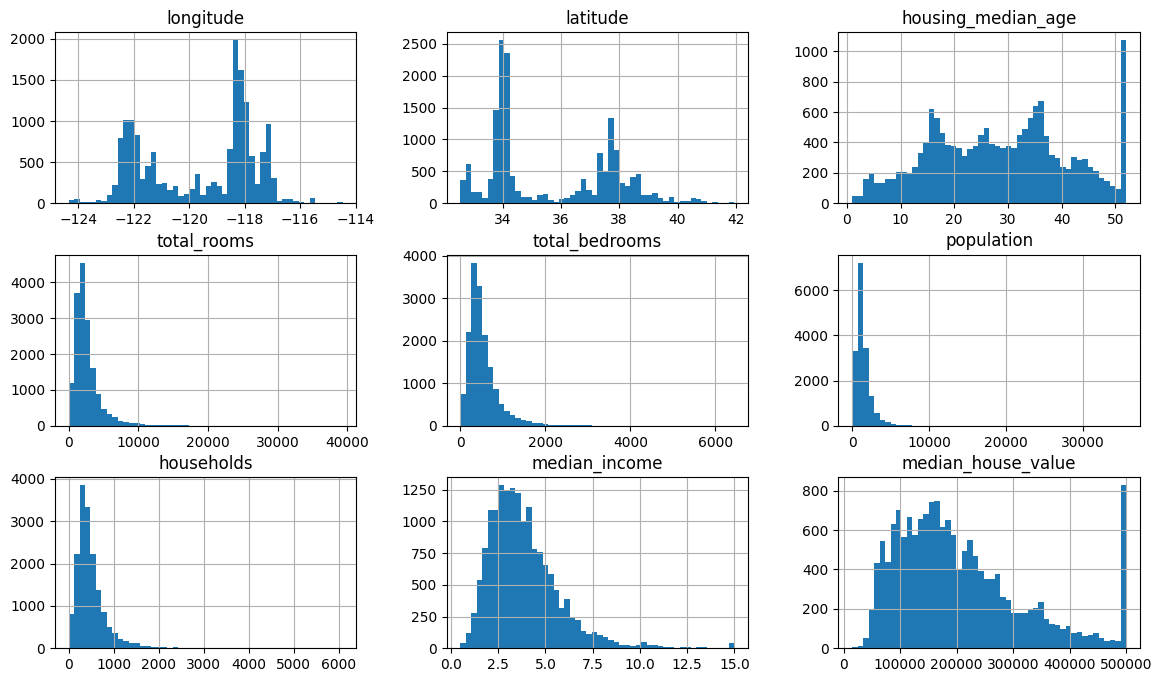

In [7]:
df_train.select_dtypes(include="float64").hist(bins=50, figsize=(14, 8))
plt.show()

In [8]:
df_train.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
longitude,1.000000,-0.924760,-0.107485,0.038185,0.063141,0.093386,0.048771,-0.018354,-0.047464,-0.016239
latitude,-0.924760,1.000000,0.008505,-0.031861,-0.062124,-0.104218,-0.065346,-0.076658,-0.142304,-0.082834
housing_median_age,-0.107485,0.008505,1.000000,-0.363561,-0.321893,-0.296493,-0.304993,-0.124403,0.106888,-0.151942
total_rooms,0.038185,-0.031861,-0.363561,1.000000,0.931977,0.859922,0.920836,0.197314,0.132111,0.222017
total_bedrooms,0.063141,-0.062124,-0.321893,0.931977,1.000000,0.879615,0.979914,-0.007403,0.046860,0.020199
population,0.093386,-0.104218,-0.296493,0.859922,0.879615,1.000000,0.908503,0.004516,-0.025016,0.030478
households,0.048771,-0.065346,-0.304993,0.920836,0.979914,0.908503,1.000000,0.013277,0.062735,0.044561
median_income,-0.018354,-0.076658,-0.124403,0.197314,-0.007403,0.004516,0.013277,1.000000,0.686498,0.865210
median_house_value,-0.047464,-0.142304,0.106888,0.132111,0.046860,-0.025016,0.062735,0.686498,1.000000,0.617210
income_cat,-0.016239,-0.082834,-0.151942,0.222017,0.020199,0.030478,0.044561,0.865210,0.617210,1.000000


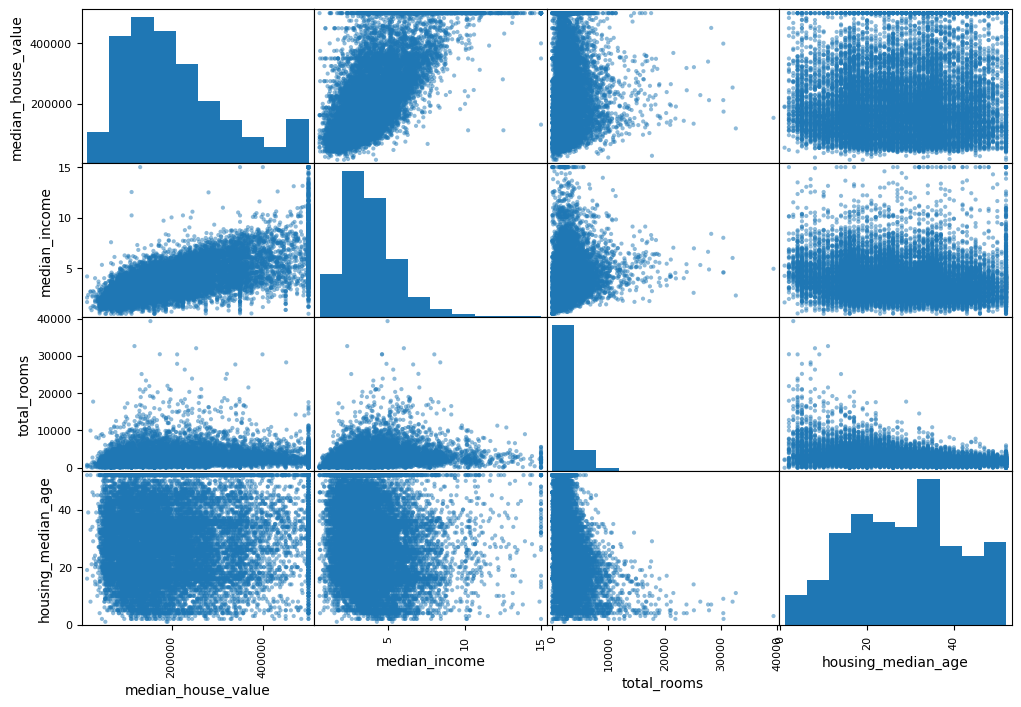

In [9]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(df_train[attributes], figsize=(12, 8))
plt.show()

### Pre-processing

In [10]:
df_X = df_train.drop(columns=['income_cat', 'median_house_value'])
df_Y = df_train[['median_house_value']]
df_X.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 19019 to 2606
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16339 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  str    
dtypes: float64(8), str(1)
memory usage: 1.3 MB


- With numerical features, missing values will be imputed by mean/median values.
- With categorical features, missing values will be imputed with most frequent category.
- Categorical with be encoded: ordinal, one-hot
- Features engineering: bedrooms_ratio, rooms_per_house, and people_per_house
- Add some cluster similarity features.
- Features transform: power law distribution, multimodal distribution
- Feature scaling: min-max scaling, standard scaling

In [11]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [12]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self # always return self!
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector, make_column_transformer

In [14]:
import sklearn
sklearn.set_config(display="diagram")

##
num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"), 
    StandardScaler())

# num_cols = df_X.select_dtypes(include='number')
# reminder

##
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

cat_cols = df_X.select_dtypes(include=["str"]).columns

##
def get_ratio(X):
    return X[:, [0]] / X[:, [1]]

ratio_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(get_ratio, feature_names_out=lambda x, y: ["ratio"]),
    StandardScaler())

bedrooms_cols = ["total_bedrooms", "total_rooms"]
rooms_per_house_cols = ["total_rooms", "households"]
people_per_house_cols = ["population", "households"]

##
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

log_cols = ["total_rooms", "total_bedrooms", "population", "households", "median_income"]

##
cluster_simil = make_pipeline(
    ClusterSimilarity(n_clusters=10, gamma=1., random_state=42))

geo_cols = ["latitude", "longitude"]

##
rbf_pipeline = make_pipeline(
    FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.]], gamma=0.1), feature_names_out="one-to-one"),
    StandardScaler())

rbf_cols = ["housing_median_age"]

In [15]:
preprocessing = ColumnTransformer([
        ("cat", cat_pipeline, cat_cols),
        ("log", log_pipeline, log_cols),
        ("bedrooms", ratio_pipeline, bedrooms_cols),
        ("rooms_per_house", ratio_pipeline, rooms_per_house_cols),
        ("people_per_house", ratio_pipeline, people_per_house_cols),
        ("geo", cluster_simil, geo_cols),
        ("mulmod", rbf_pipeline, rbf_cols)
    ],
    remainder=num_pipeline)

X_preprocessed = preprocessing.fit_transform(df_X)
X_preprocessed.shape

(16512, 24)

In [19]:
df_X_preprocessed = pd.DataFrame(X_preprocessed, 
                                 columns=preprocessing.get_feature_names_out(), index=df_X.index)
print(df_X_preprocessed.columns)

Index(['cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN', 'log__total_rooms',
       'log__total_bedrooms', 'log__population', 'log__households',
       'log__median_income', 'bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'mulmod__housing_median_age'],
      dtype='str')


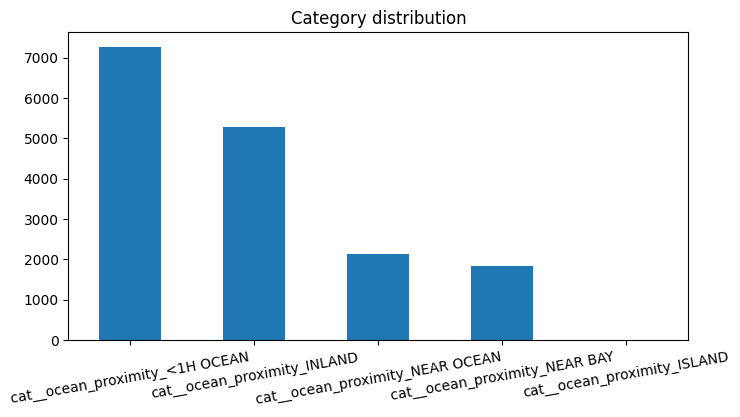

In [106]:
cat_cols = df_X_preprocessed.filter(like="cat_")

counts = cat_cols.sum().sort_values(ascending=False)

counts.plot(kind="bar", figsize=(8,4), rot=10)
plt.title("Category distribution")
plt.show()

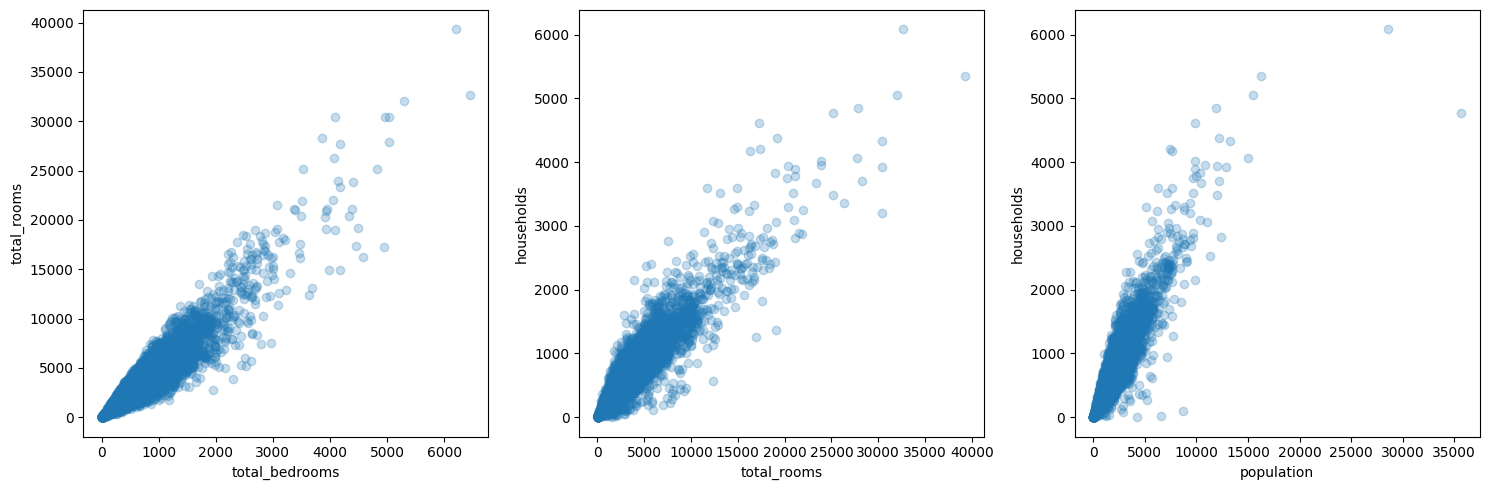

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

pairs = [
    bedrooms_cols,
    rooms_per_house_cols,
    people_per_house_cols
]

for i, (a_col, b_col) in enumerate(pairs):    
    ax = axes[i]
    ax.scatter(x=df_X[a_col], y=df_X[b_col], alpha=0.25)
    
    ax.set_xlabel(a_col)
    ax.set_ylabel(b_col)

plt.tight_layout()
plt.show()

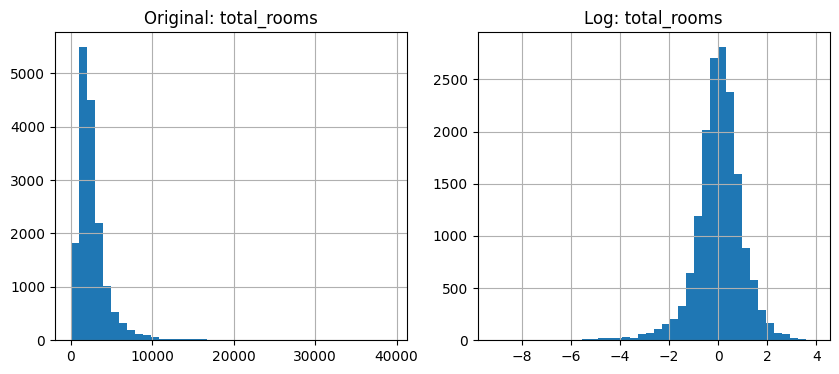

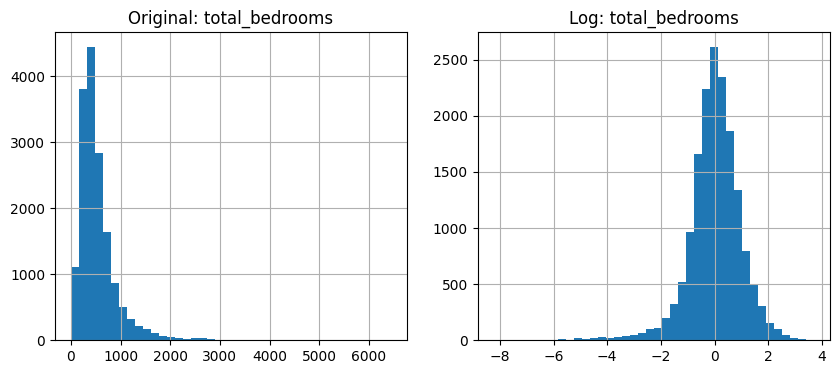

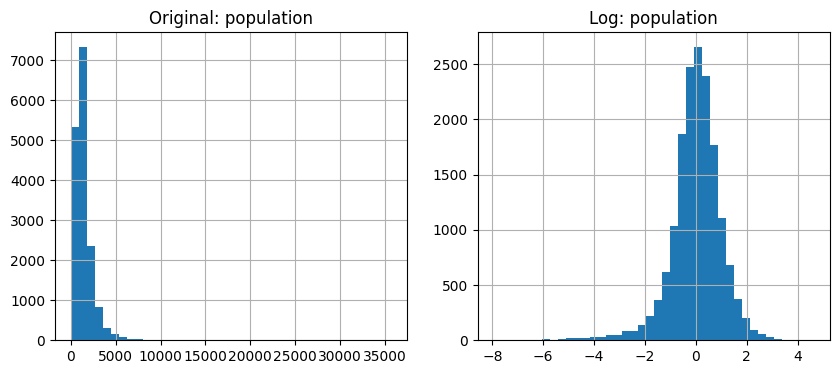

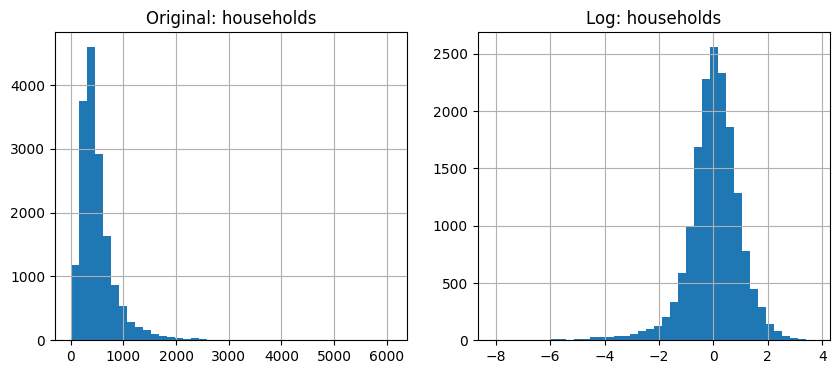

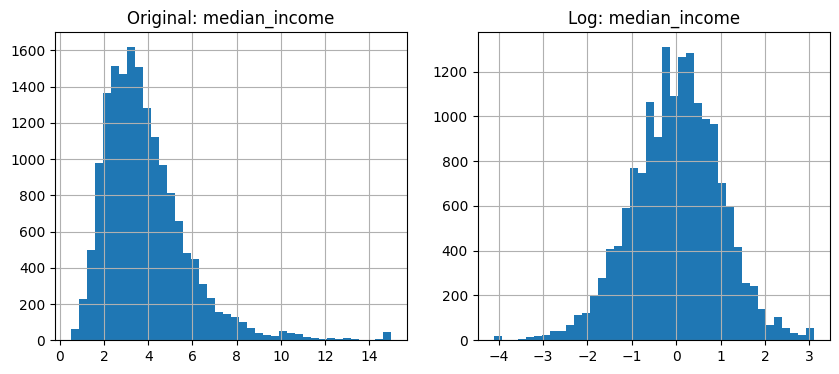

In [90]:
for col in log_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    
    df_X[col].hist(ax=axes[0], bins=40)
    axes[0].set_title(f"Original: {col}")
    
    df_X_preprocessed[f"log__{col}"].hist(ax=axes[1], bins=40)
    axes[1].set_title(f"Log: {col}")
    
    plt.show()

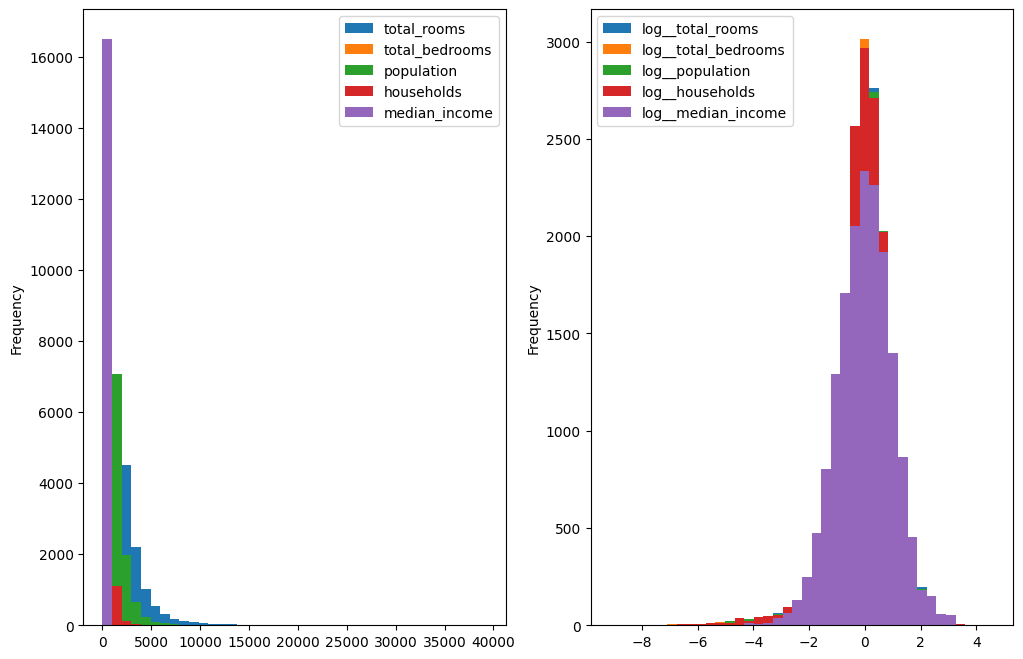

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

df_X[log_cols].plot.hist(ax=axes[0], bins=40)
df_X_preprocessed.filter(like="log").plot.hist(ax=axes[1], bins=40)
plt.show()

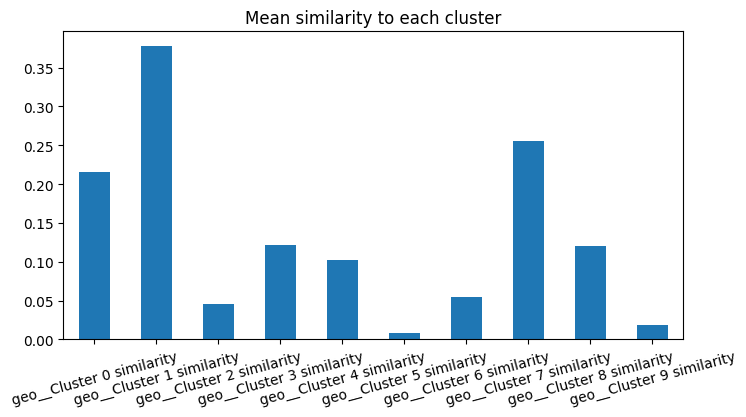

In [104]:
geo_cols = df_X_preprocessed.filter(like="geo__Cluster")

geo_cols.mean().plot(kind="bar", figsize=(8,4), rot=15)
plt.title("Mean similarity to each cluster")
plt.show()

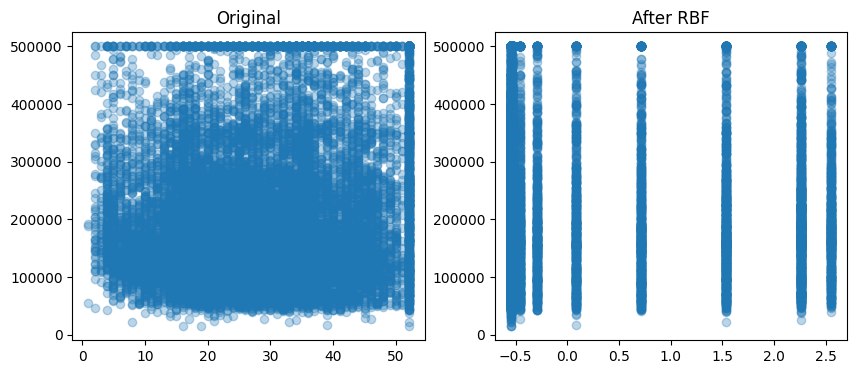

In [107]:
col = "housing_median_age"
trans_col = "mulmod__housing_median_age"

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(df_X[col], df_Y, alpha=0.3)
plt.title("Original")

plt.subplot(1,2,2)
plt.scatter(df_X_preprocessed[trans_col], df_Y, alpha=0.3)
plt.title("After RBF")

plt.show()

### Training Model

#### Linear regression

In [108]:
from sklearn.linear_model import LinearRegression

linreg_pipeline = make_pipeline(preprocessing, LinearRegression())
linreg_pipeline.fit(df_X, df_Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, default=0.3I

In [109]:
Y_linreg_predict = linreg_pipeline.predict(df_X)
Y_label = df_Y.to_numpy()

print(Y_linreg_predict[0:10].round(2).tolist())
print(Y_label[0:10].tolist())

[[152507.3], [235631.49], [106895.11], [425639.9], [159443.8], [134370.33], [149315.64], [180822.35], [287750.91], [101273.47]]
[[218800.0], [187500.0], [82100.0], [500001.0], [163900.0], [112200.0], [182900.0], [133500.0], [287500.0], [86600.0]]


In [110]:
from sklearn.metrics import root_mean_squared_error

linreg_rmse = root_mean_squared_error(Y_label, Y_linreg_predict)
linreg_rmse

69130.99896874871

In [111]:
from sklearn.model_selection import cross_val_score

linreg_rmses = -cross_val_score(linreg_pipeline, df_X, df_Y, 
                                scoring="neg_root_mean_squared_error", cv=10)

pd.Series(linreg_rmses).describe()

count       10.000000
mean     69778.791186
std       2759.808301
min      66495.697823
25%      67610.303390
50%      69365.606168
75%      70886.526373
max      74641.190815
dtype: float64

#### Decision Regressor

In [112]:
from sklearn.tree import DecisionTreeRegressor

dectre_pipeline = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
dectre_pipeline.fit(df_X, df_Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, default

In [113]:
Y_dectree_predict = dectre_pipeline.predict(df_X)
dectree_rmse = root_mean_squared_error(Y_label, Y_dectree_predict)
dectree_rmse

0.0

In [114]:
dectree_rmses = -cross_val_score(dectre_pipeline, df_X, df_Y, 
                                scoring="neg_root_mean_squared_error", cv=10)

pd.Series(dectree_rmses).describe()

count       10.000000
mean     65652.606063
std       2154.832846
min      62207.112780
25%      64500.041332
50%      65369.319886
75%      67371.716307
max      68686.989746
dtype: float64

#### Random Forest Regressor

In [115]:
from sklearn.ensemble import RandomForestRegressor

ranfor_pipeline = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))

ranfor_rmses = -cross_val_score(ranfor_pipeline, 
                                df_X, df_Y, scoring="neg_root_mean_squared_error", cv=10)
pd.Series(ranfor_rmses).describe()

/Users/haidong2k3/Developer/Projects/House-Price-Prediction-homl/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/haidong2k3/Developer/Projects/House-Price-Prediction-homl/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/haidong2k3/Developer/Projects/House-Price-Prediction-homl/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/haidong2k3/Develop

count       10.000000
mean     46970.959427
std       1995.173023
min      44900.967070
25%      45901.633536
50%      46372.866262
75%      47233.330162
max      50857.947975
dtype: float64

### Model Fine-tuning

#### Grid Search

In [118]:
print(cluster_simil)

Pipeline(steps=[('clustersimilarity', ClusterSimilarity(random_state=42))])


In [121]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
    ])

param_grid = [
    {'preprocessing__geo__clustersimilarity__n_clusters': [5, 8, 10],
    'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__clustersimilarity__n_clusters': [10, 15],
    'random_forest__max_features': [6, 8, 10]},
    ]

grid_search = GridSearchCV(full_pipeline, param_grid, 
                           cv=3, scoring='neg_root_mean_squared_error')

grid_search.fit(df_X, df_Y)


/Users/haidong2k3/Developer/Projects/House-Price-Prediction-homl/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/haidong2k3/Developer/Projects/House-Price-Prediction-homl/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/haidong2k3/Developer/Projects/House-Price-Prediction-homl/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/haidong2k3/Develop

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__cl...rsimilarity__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__cl...rsimilarity__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbos

In [122]:
grid_search.best_params_

{'preprocessing__geo__clustersimilarity__n_clusters': 15,
 'random_forest__max_features': 6}

In [124]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res = cv_res.sort_values(by="mean_test_score", ascending=False)

cv_res = cv_res[["param_preprocessing__geo__clustersimilarity__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,43096,43521,45242,43953
13,15,8,43677,43332,45688,44232
14,15,10,43892,44144,46103,44713
7,10,6,44683,44054,46888,45208
9,10,6,44683,44054,46888,45208


#### Random Search

In [125]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__clustersimilarity__n_clusters': randint(low=3, high=50), 'random_forest__max_features': randint(low=2, high=20)}
rnd_search = RandomizedSearchCV(full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3, scoring='neg_root_mean_squared_error', random_state=42)
rnd_search.fit(df_X, df_Y)

/Users/haidong2k3/Developer/Projects/House-Price-Prediction-homl/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/haidong2k3/Developer/Projects/House-Price-Prediction-homl/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/haidong2k3/Developer/Projects/House-Price-Prediction-homl/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/haidong2k3/Develop

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__cl...rsimilarity__n_clusters': <scipy.stats....t 0x11b89b740>, 'random_forest__max_features': <scipy.stats....t 0x11db84d40>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valida

In [127]:
print(rnd_search.best_params_)

cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res = cv_res.sort_values(by="mean_test_score", ascending=False)

cv_res = cv_res[["param_preprocessing__geo__clustersimilarity__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

{'preprocessing__geo__clustersimilarity__n_clusters': 45, 'random_forest__max_features': 9}


,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41542,41084,43528,42052
8,32,7,41795,41170,43862,42276
5,42,4,42500,41300,44061,42620
0,41,16,42541,42126,44650,43106
2,23,8,42691,42314,44793,43266


In [128]:
final_model = rnd_search.best_estimator_
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.  , 0.09, 0.  , 0.  , 0.  , 0.01, 0.01, 0.01, 0.01, 0.19, 0.07,
       0.06, 0.05, 0.01, 0.01, 0.02, 0.01, 0.01, 0.  , 0.01, 0.02, 0.  ,
       0.01, 0.01, 0.02, 0.  , 0.03, 0.01, 0.02, 0.01, 0.01, 0.02, 0.  ,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.  , 0.  , 0.01, 0.03, 0.01, 0.  , 0.  , 0.01, 0.01,
       0.01, 0.02, 0.01, 0.01])

In [129]:
sorted(zip(feature_importances, 
           final_model["preprocessing"].get_feature_names_out()), reverse=True)

[(np.float64(0.1888198994972804), 'log__median_income'),
 (np.float64(0.0864417271693056), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.07254816568998175), 'bedrooms__ratio'),
 (np.float64(0.05685604199244631), 'rooms_per_house__ratio'),
 (np.float64(0.05014167157855738), 'people_per_house__ratio'),
 (np.float64(0.03295515154193698), 'geo__Cluster 13 similarity'),
 (np.float64(0.027285501145166945), 'geo__Cluster 36 similarity'),
 (np.float64(0.021853257867856392), 'geo__Cluster 15 similarity'),
 (np.float64(0.02051103506363722), 'geo__Cluster 11 similarity'),
 (np.float64(0.020113828014031176), 'geo__Cluster 7 similarity'),
 (np.float64(0.0197881094445875), 'geo__Cluster 2 similarity'),
 (np.float64(0.01724132033212167), 'geo__Cluster 43 similarity'),
 (np.float64(0.015881970071737368), 'geo__Cluster 18 similarity'),
 (np.float64(0.014188094210973834), 'geo__Cluster 35 similarity'),
 (np.float64(0.014183587987790836), 'geo__Cluster 6 similarity'),
 (np.float64(0.013461598566884066),

### Evaluation

In [130]:
url_raw_test = "../data/raw/testset.csv"
df_test = pd.read_csv(url_raw_test, index_col=0)
df_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
13624,-117.25,34.11,30.0,2173.0,560.0,1509.0,486.0,1.4079,67700.0,INLAND,2
4231,-118.30,34.11,52.0,3136.0,675.0,1213.0,606.0,3.5806,391900.0,<1H OCEAN,3
15791,-122.42,37.77,52.0,759.0,323.0,421.0,255.0,2.0548,162500.0,NEAR BAY,2
7027,-118.09,33.96,36.0,1116.0,229.0,719.0,233.0,3.4250,163200.0,<1H OCEAN,3
13340,-117.67,34.02,16.0,3042.0,524.0,1516.0,475.0,4.8906,178500.0,INLAND,4


In [131]:
X_test = df_test.drop("median_house_value", axis=1)
y_test = df_test["median_house_value"].copy()

final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

42408.72233320381


In [132]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [133]:
print(rmse_lower)
print(rmse_upper)

40384.214422595585
44894.105901502255


### Export model

In [ ]:
import joblib

url_model = "../models/my_housing_model.pkl"
joblib.dump(final_model, url_model)